In [42]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
import torchvision.transforms as transforms
from torchvision.models import resnet18
import json
import os
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torchvision.models import ResNet18_Weights

In [43]:
MODEL_PATH = r"./TAI_HW2_Files/Model Weights (Q1 & Q2)/resnet18-f37072fd.pth"
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print("Using device:", device)

model = resnet18(weights=None)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Model loaded from", MODEL_PATH)

Using device: mps
Model loaded from ./TAI_HW2_Files/Model Weights (Q1 & Q2)/resnet18-f37072fd.pth


In [44]:
DATASET_WORKER = 0
SILIANCY_MAP_THRESHOLD = 0.1

In [45]:
dataset_root = "./dataset/tiny-imagenet-200"
categories = ResNet18_Weights.DEFAULT.meta["categories"]


class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir):
        self.transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225],
                ),
            ]
        )

        self.root_dir = root_dir
        self.pics = []

        imagenet_wnids = os.path.join(self.root_dir, "imagenet_wnids.txt")
        imagenet_wnid_to_idx = {}
        with open(imagenet_wnids, "r") as f:
            data = json.load(f)
            assert len(data) == 1000
            for i in range(1000):
                wnid = data[str(i)][0]
                imagenet_wnid_to_idx[wnid] = i

        dir = os.path.join(root_dir, "train")
        for wnid in os.listdir(dir):
            wnid_dir = os.path.join(dir, wnid)
            if not os.path.isdir(wnid_dir):
                continue
            for img_name in os.listdir(os.path.join(wnid_dir, "images")):
                img_path = os.path.join(wnid_dir, "images", img_name)
                label = imagenet_wnid_to_idx[wnid]
                self.pics.append((img_path, label))

    def __len__(self):
        return len(self.pics)

    def __getitem__(self, index):
        img_path, label = self.pics[index]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform:
                img_tensor = self.transform(img)
            else:
                img_tensor = transforms.ToTensor()(img)

        return img_tensor, label


dataset = TinyImageNetDataset(dataset_root)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=DATASET_WORKER,
)

print("dataset length", len(dataset))
sample_img, sample_label = dataset[0]
print("image shape", sample_img.shape)
print("image label", sample_label)

dataset length 100000
image shape torch.Size([3, 224, 224])
image label 427


In [46]:
def get_correct_indexes(dataset, count=5):
    ans = []
    processed_labels = set()
    with torch.no_grad():

        # since data is sorted by label and we want different labels, we can jump by 500 samples to be faster. lowering it can get more correct samples but will be slower.
        for idx in range(0, len(dataset), 500):
            image, label = dataset[idx]
            if label in processed_labels:
                continue
            image = image.unsqueeze(0).to(device)
            label = torch.tensor([label], device=device)

            logits = model(image)
            pred = torch.argmax(logits, dim=1)

            if pred.item() == label.item():
                ans.append(idx)
                processed_labels.add(label.item())
                if len(ans) >= count:
                    return ans
    raise ValueError(
        f"Could not find {count} correct samples in the dataset. Found only {len(ans)}."
    )


indexes = get_correct_indexes(dataset, count=5)

for idx in indexes:
    _, label = dataset[idx]
    print(f"Index: {idx}, Label: {label}, Category: {categories[label]}")

Index: 0, Label: 427, Category: barrel
Index: 2000, Label: 25, Category: European fire salamander
Index: 5500, Label: 107, Category: jellyfish
Index: 17000, Label: 570, Category: gasmask
Index: 19000, Label: 105, Category: koala


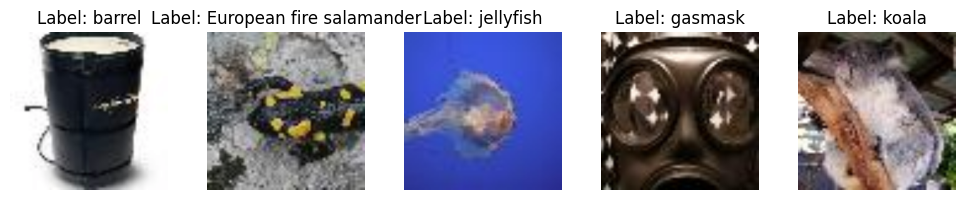

In [47]:
def untransform_image(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img.cpu() * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = (img * 255).clip(0, 255).astype(np.uint8)
    return img


plt.figure(figsize=(10, 2))
np.random.seed(42)
for i in range(5):
    img, label = dataset[indexes[i]]
    img = untransform_image(img)
    plt.subplot(1, 5, i + 1)
    plt.title(f"Label: {categories[label]}")
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.savefig('./report/images/q1_samples.png')

In [48]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

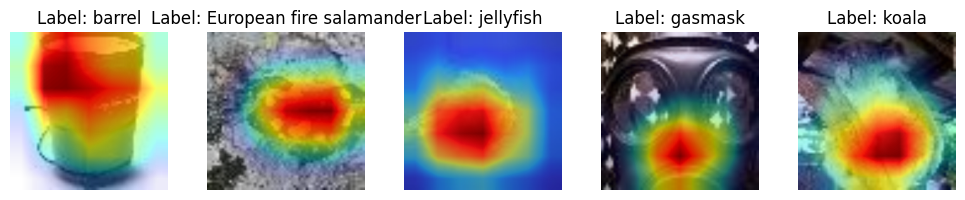

In [49]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

    def _save_activations(self, module, inputs, output):
        self.activations = output

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def register_hooks(self):
        self._forward_handle = self.target_layer.register_forward_hook(
            self._save_activations
        )
        self._backward_handle = self.target_layer.register_full_backward_hook(
            self._save_gradients
        )

    def remove_hooks(self):
        self._forward_handle.remove()
        self._backward_handle.remove()

    def __call__(self, input_tensor):
        *_, h, w = input_tensor.shape
        self.register_hooks()
        logits = self.model(input_tensor)
        self.remove_hooks()

        class_idx = torch.argmax(logits, dim=1)

        one_hot = torch.zeros_like(logits)
        one_hot[0, class_idx] = 1.0

        self.model.zero_grad()
        logits.backward(gradient=one_hot)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = F.interpolate(
            cam,
            (h, w),
            mode="bilinear",
            align_corners=False,
        )

        cam_min = cam.amin(dim=(2, 3), keepdim=True)
        cam_max = cam.amax(dim=(2, 3), keepdim=True)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.squeeze(1)


grad_cam = GradCAM(model, model.layer4[-1].conv2)

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image, label = dataset[indexes[i]]
    input_tensor = image.unsqueeze(0).to(device)

    cam_map = grad_cam(input_tensor)
    heatmap = cam_map[0].detach().cpu().numpy()

    plt.imshow(untransform_image(image))
    plt.title(f"Label: {categories[label]}")
    plt.imshow(heatmap, cmap="jet", alpha=heatmap)
    plt.axis("off")

plt.tight_layout()
plt.savefig('./report/images/q1_gradcam.png')

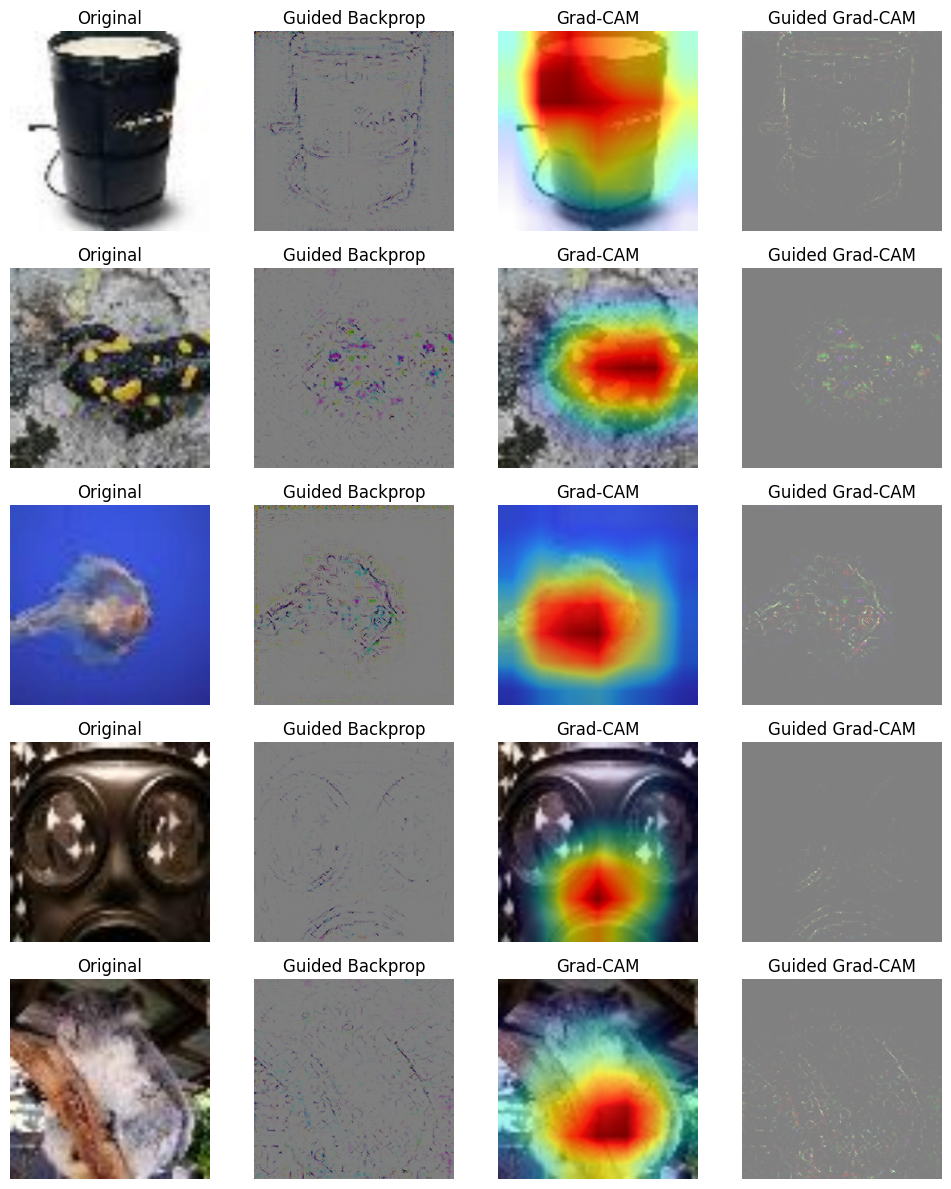

In [50]:
class GuidedBackprop:
    def __init__(self, model):
        self.model = model
        for module in self.model.modules():
            if isinstance(module, nn.ReLU):
                module.inplace = False

    def _guided_backprop_hook(self, module, grad_input, grad_output):
        if not grad_input or grad_input[0] is None:
            return grad_input
        grad_in = list(grad_input)
        grad_in[0] = torch.clamp(grad_in[0], min=0.0).clone()
        return tuple(grad_in)

    def _register_hooks(self):
        self.handles = []
        for module in self.model.modules():
            if isinstance(module, nn.ReLU):
                self.handles.append(
                    module.register_full_backward_hook(self._guided_backprop_hook)
                )

    def _remove_hooks(self):
        for handle in self.handles:
            handle.remove()

    def __call__(self, input_tensor, class_idx=None):
        input_tensor = input_tensor.clone().detach().requires_grad_(True)
        self._register_hooks()
        logits = self.model(input_tensor)

        class_idx = torch.argmax(logits, dim=1)

        score = logits[0][class_idx]
        self.model.zero_grad(set_to_none=True)
        score.backward()
        self._remove_hooks()

        guided_grads = input_tensor.grad.detach()[0]
        guided_grads = torch.clamp(guided_grads, min=0.0)
        guided_grads = guided_grads.permute(1, 2, 0).cpu().numpy()
        guided_grads = (guided_grads - guided_grads.min()) / (
            guided_grads.max() - guided_grads.min() + 1e-8
        )
        return guided_grads


def guided_gradcam(guided_backprop_map, cam_map):
    cam = cam_map[0].detach().cpu().numpy()[..., None]
    ans = guided_backprop_map * cam
    ans = (ans - ans.min()) / (ans.max() - ans.min() + 1e-8)
    return ans


guided_backprop = GuidedBackprop(model)

plt.figure(figsize=(10, 12))
for i in range(5):
    image, label = dataset[indexes[i]]
    input_tensor = image.unsqueeze(0).to(device)
    pred_idx = torch.argmax(model(input_tensor), dim=1)

    cam_map = grad_cam(input_tensor)
    heatmap = cam_map[0].detach().cpu().numpy()
    gb_map = guided_backprop(input_tensor, class_idx=pred_idx)
    ggcam_map = guided_gradcam(gb_map, cam_map)

    plt.subplot(5, 4, i * 4 + 1)
    plt.imshow(untransform_image(image))
    plt.title(f"Original")
    plt.axis("off")

    plt.subplot(5, 4, i * 4 + 2)
    plt.imshow(np.abs(gb_map- 0.5) )
    plt.title("Guided Backprop")
    plt.axis("off")

    plt.subplot(5, 4, i * 4 + 3)
    plt.imshow(untransform_image(image))
    plt.imshow(heatmap, cmap="jet", alpha=heatmap)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(5, 4, i * 4 + 4)
    plt.imshow(ggcam_map, cmap="jet", alpha=0.5)
    plt.title("Guided Grad-CAM")
    plt.axis("off")

plt.tight_layout()

plt.savefig('./report/images/q1_guidedgradcam.png')